# 자기회귀이동평균 프로세스

- 자기회귀 프로세스와 이동평균 프로세스의 조합

- 자기회귀 프로세스와 마찬가지로 현재의 값은 이전값과 상수에 선형적으로 의존하고, 이동평균 프로세스와 마찬가지로 수열의 평균, 현재 오차, 과거 오차에 선형적으로 의존

- 자기회귀이동평균 프로세스는 ARMA(p, q) 로 표시함
    - p는 자기회귀 부분의 차수
    - q는 이동평균 부분의 차수

- $$y_t = C + \phi_1 y_{t-1} + \cdots + \phi_p y_{t-p} + \epsilon_t + \theta_1\epsilon_{t-1} + \cdots + \theta_q\epsilon_{t-q}$$

- 차수 p와 q는 각각 자기회귀 및 이동평균 부분에 대한 매개변수의 개수를 뜻함
    - ARMA(1, 1) 프로세스의 경우, AR(1)과 MA(1)을 조합한 것
    - $AR(1) := y_t = C + \phi_{1}y_{t-1} + \epsilon_t$
    - $MA(1) := y_t = \mu + \epsilon_t + \theta_1\epsilon_{t-1}$
    - $ARMA(1, 1) := y_t = C + \phi_{1}y_{t-1} + \epsilon_t + \theta_1\epsilon_{t-1}$

- p 가 0인 경우, MA(q) 프로세스와 동일한 ARMA(0, q) 프로세스를 얻게 됨

- q 가 0인 경우, AR(p) 프로세스와 동일한 ARMA(p, 0) 프로세스를 얻게 됨

- ARMA(p, q) 프로세스를 모델링하고 예측하려면 차수 p와 q를 알아내야 함

# 정상적 ARMA 프로세스 식별

<img src = "./image/arma_식별.png" width = 600 height = 600>

- ACF 그래프와 PACF 그래프를 확인하는 단계에서 두 가지 도식 모두에서 유의한 계수가 존재하다가 갑자기 유의하지 않게되는 명확한 지연 시점을 확인할 수 없다면 ARMA(p, q) 프로세스가 존재한다고 할 수 있음

## ARMA 프로세스 식별 시뮬레이션

- 시뮬레이션의 목적
    - ARMA(p, q) 프로세스의 차수 p를 식별하기 위해 PACF 그래프를 사용할 수 없음
    - ARMA(p, q) 프로세스의 차수 q를 식별하기 위해 ACF 그래프를 사용할 수 없음을 입증

In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [2]:
# ARMA 프로세스 랜덤 생성
np.random.seed(42)

ar1 = np.array([1, -0.33])
ma1 = np.array([1, 0.9])

ARMA_1_1 = ArmaProcess(ar1, ma1).generate_sample(nsample = 1000)

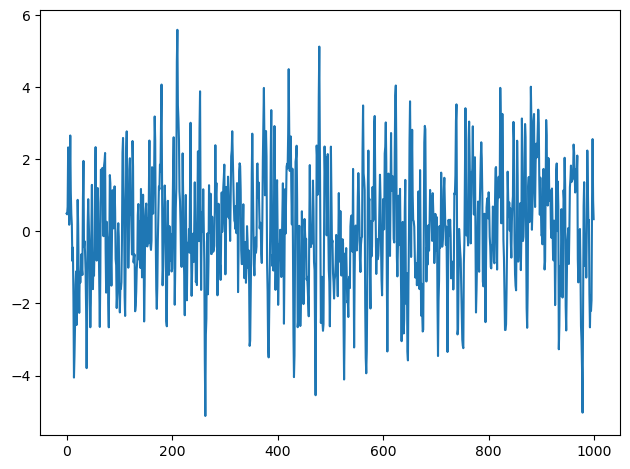

In [3]:
fig, ax = plt.subplots()

ax.plot(ARMA_1_1)

plt.tight_layout()

plt.show()

In [4]:
# 정상성 테스트
ADF_result = adfuller(ARMA_1_1)

print(f"ADF Statistic: {ADF_result[0]}") # ADF 통계 출력
print(f"p-value: {ADF_result[1]}") # p-value 출력

ADF Statistic: -6.429878682042682
p-value: 1.7078466680097572e-08


- p-값이 0.05보다 훨씬 작으므로 시뮬레이션된 ARMA(1, 1) 프로세스는 정상성을 만족함

- 기존 플로우차트에 따라 ACF를 시각화하고 ARMA(1, 1) 프로세스의 이동평균 부분의 차수를 유추할 수 있는지 확인

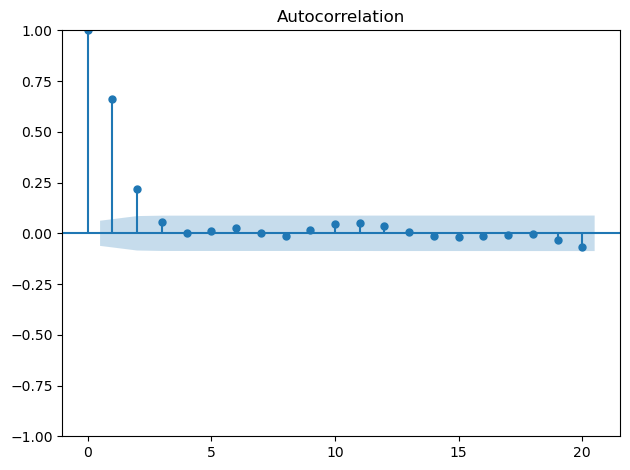

In [5]:
plot_acf(ARMA_1_1, lags = 20)

plt.tight_layout()
plt.show()

- 사인 곡선 패턴을 볼 수 있어 자기회귀 프로세스가 있음을 나타냄

- 다만 우리는 ARMA(1, 1) 프로세스를 시뮬레이션 했으므로 지연 1까지만 유의해야하는데, 그래프에서는 마지막 유의한 시점이 지연 2로 보임
    - 따라서 ACF 도식은 ARMA(1, 1) 프로세스의 차수 q에 대해 유용한 정보를 제공하지 못함

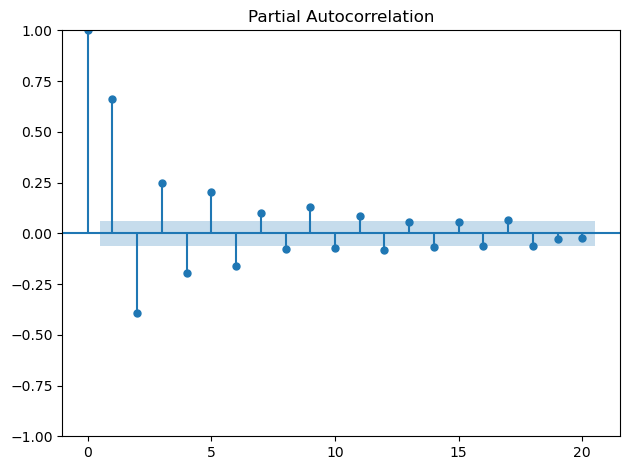

In [6]:
# PACF 시각화
plot_pacf(ARMA_1_1, lags = 20)

plt.tight_layout()
plt.show()

- 사인 곡선 패턴을 볼 수 있으며, 차수 p의 값을 유추할 수 없음
    - ARMA(1, 1) 프로세스를 시뮬레이션한 데이터이지만 지연 1 이후에도 계수가 유의하게 보임
 
- 따라서 PACF 그래프는 ARMA(p, q) 프로세스의 차수 p를 구하는 데 사용할 수 없음

- ACF 그래프와 PACF 그래프에서 모두 유의했던 계수가 특정 지연 이후 상관관계를 보이지 않는 패턴이 없다면 ARMA(p, q) 프로세스가 있다는 결론을 내릴 수 있음

- 차수에 따라 모델에 포함해야 하는 매개변수의 개수가 결정되므로 프로세스의 차수를 결정하는 것이 모델링과 예측의 핵심임

- ARMA(p, q) 프로세스의 경우 ACF와 PACF 그래프가 유용하지 않으므로 모델에 적합한 (p, q) 조합을 찾을 수 있는 일반적인 모델링 절차를 고안해야 함

# 일반적 모델링 절차

- ACF 그래프와 PACF 그래프 모두 사인 곡선이나 감쇄 패턴을 보이는 경우, 해당 시계열을 ARMA(p, q) 프로세스로 모델링 할 수 있음

- 그러나 두 그래프 모두 차수를 결정하는 데 유용하지 않음
    - ARMA(1, 1) 프로세스를 시각화했는데 지연 1 이후에도 계수가 유의한 것으로 보임

<img src = "./image/arma모델링_절차.png" height = 600 width = 600>

- 새로운 모델링 절차에서는 ACF와 PACF 시각화가 완전히 제거됨
    - 도식의 정성적 분석에 의존하는 대신 전적으로 통계적 테스트와 정량적 기준에 따라 모델을 선택할 수 있음
 
- 데이터 수집

- 정상성 테스트하고, 그에 따라 변환 적용

- 양수인 정수만 사용한다는 점에 유의하면서 p와 q에 가능한 한 여러 가지 값을 나열
    - 이 값을 활용하여 여러 가지 ARMA(p, q) 를 훈련
 
- 이후 AIC를 계산
    - 각 모델의 품질 수준을 비교하는 정량적 기준
 
- AIC가 가장 낮은 모델을 선택

- 모델의 실제값과 예측값의 차이인 모델의 잔차를 분석
    - 이상적으로 모델을 선택한 경우 잔차는 백색소음처럼 보임
        - 예측값과 실제값의 차이가 무작위성에서 오기 때문
        - 즉, 잔차가 상관관계 없이 독립적으로 분포됨
 
    - Q-Q plot 을 살펴보거나 융-박스 테스트(Ljung-Box test)를 실행하여 검증할 수도 있음
 
- 검증 결과 잔차가 완전히 무작위라는 결론에 도달하면, 모델을 사용하여 예측을 수행
    - 그렇지 않다면 p와 q에 대해 다른 값의 조합을 시도해보는 단계부터 다시 시작

## 아카이케 정보 기준(AIC)

- 훈련할 모델들 중에서 가장 적합한 모델을 선택하는 방법을 정해야 함

- 여기서는 아카이케 정보 기준(AIC)을 사용하여 최적의 모델 선택

- AIC는 모델의 품질을 다른 모델들과 비교하여 상대적으로 정량화

- 모델을 데이터에 학습할 때 일부 정보가 손실되므로 AIC는 모델에 의해 손실되는 정보의 양을 상대적으로 정량화하고, 모델들을 정량적으로 비교할 수 있음
    - 손실된 정보가 적을수록 AIC 값은 낮고 모델이 더 우수하다고 판정
 
    - $$AIC = 2k - 2\ln(\hat{L})$$
 
    - $k$ : 추정 매개변수들의 개수
 
    - $\hat{L}$ : 모델의 가능도 함수의 최대값
 
    - $\ln$ : 로그

- 추정 매개변수의 개수 k는 ARMA(p, q) 모델의 차수(p, q) 와 직접적인 연관이 있음
    - 차수 (p, q)가 증가함에 따라 매개변수의 개수 k가 증가하고 결국 AIC가 증가하므로, 더 복잡한 모델을 훈련할수록 AIC 점수에 불이익을 받음
    - 예) ARMA(2, 2) 모델을 훈련할 때 2 + 2 = 4개의 매개변수를 추정해야 함
    - ARMA(3, 4) 모델을 훈련할 때는 3 + 4 = 7개의 매개변수를 추정해야 함

- 가능도 함수는 모델이 훈련하기에 적합한지를 측정
    - 확률 분포 함수의 반대 개념으로 볼 수 있음
    - 확률 분포 함수는 매개변수가 정해진 모델에서 데이터 요소가 관측될 확률을 측정
    - 가능도 함수는 관측된 데이터 집합에서 모델의 여러 가지 매개변수가 관측된 데이터를 생성할 가능성을 추정
        - 예) 내가 관측한 데이터가 ARMA(1, 1) 모델에서 나올 가능성이 얼마나 될까? 라는 질문에 대한 답
        - 가능성이 매우 높다면($\hat{L}$이 크다면) ARMA(1, 1) 모델이 데이터에 잘 맞는다는 것

- AIC는 과소적합과 과대적합 사이에서도 균형을 유지할 수 있음
    - 과대적합 모델은 $\hat{L}$ 이 매우 커지고 AIC가 많이 감소할 수 있지만, 매개변수의 개수 k도 함께 커질 수 있어 AIC에 불이익을 줄 수 있음
    - 과소적합 모델은 매개변수의 개수가 적으므로 k가 작을 것이지만, 적합도가 낮기 때문에 가능도 함수의 최댓값도 작아져 AIC가 불이익을 받게됨

    - 따라서 AIC를 사용하면 모델의 매개변수의 개수와 훈련 데이터에 대한 적합도 사이에서 균형을 잡게 됨

- AIC는 다른 모델에 상대적으로 모델의 품질을 정량화 함
    - AIC는 해당 모델 집단에서 가장 좋은 모델을 상대적으로 결정하는 데 도움이 될 뿐임

## AIC를 사용하여 모델 선택

- 시뮬레이션된 프로세스가 정상적이라는 결론이 나왔으므로 p와 q의 가능한 값 목록 정의

- 범위는 임의적인 것으로, 원한다면 큰 범위에서도 시도해 볼 수 있음

In [7]:
ps = range(0, 4, 1)
qs = range(0, 4, 1)

order_list = list(product(ps, qs)) # 여러 반복가능한 객체들의 모든 조합 생성
print(order_list)

[(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (2, 3), (3, 0), (3, 1), (3, 2), (3, 3)]


- 가능한 값 목록을 생성했으므로 고유한 16개의 모든 ARMA(p, q) 모델을 훈련해봐야 함

In [8]:
def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    '''
    endog : 예측하고자 하는 대상 시계열 데이터
    order_list : p, q 조합 리스트
    '''
    results = [] # 차수 p, q와 그에 해당하는 AIC를 저장할 리스트

    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(endog, order = (order[0], 0, order[1])).fit(disp = False)

        except:
            continue

        aic = model.aic # 모델의 AIC를 계산
        results.append([order, aic]) # 결과 리스트에 p, q 조합과 AIC를 추가

    result_df = pd.DataFrame(results)
    result_df.columns = ["(p, q)", "AIC"]

    # 오름차순 정렬, AIC가 낮을수록 좋음
    result_df = result_df.sort_values(by = "AIC", ascending = True).reset_index(drop = True)

    return result_df

In [9]:
result_df = optimize_ARMA(ARMA_1_1, order_list)
result_df

  0%|          | 0/16 [00:00<?, ?it/s]

,"(p, q)",AIC
0,"(1, 1)",2801.407785
1,"(2, 1)",2802.906070
2,"(1, 2)",2802.967762
3,"(0, 3)",2803.666793
4,"(1, 3)",2804.524027
5,"(3, 1)",2804.588567
6,"(2, 2)",2804.822282
7,"(2, 3)",2806.175380
8,"(3, 3)",2806.288040
9,"(3, 2)",2806.894930


- ARMA(1, 1) 모델이 데이터에 훈련한 모든 모델들 중 상대적으로 가장 좋은 모델임

## 잔차 분석

- 모델의 잔차 분석을 수행하여 절대적인 품질을 측정

- "Q-Q plot이 직선을 나타내는가" 와 "잔차들이 상관관계가 없는가" 라는 질문에 대한 답이 모두 "예" 라면 예측을 수행할 준비가 된 모델임
    - 그렇지 않으면 다른 p, q 조합들에 대해 시도해봐야 함
 
- 현재 시뮬레이션된 프로세스의 수식은
    - $$y_t = 0.33y_{t-1} + 0.9\epsilon_{t-1} + \epsilon_t$$

- ARMA(1, 1) 모델을 위의 프로세스에 훈련한 뒤 모델 계수를 완벽하게 추정했다고 하면 모델로 표현하는 수식은
    - $$\hat{y_t} = 0.33y_{t-1} + 0.9\epsilon_{t-1}$$

- 잔차는 모델에서 나온 값과 시뮬레이션된 프로세스의 실제값의 차이
    - 즉 잔차의 수식은
    - $$residuals = 0.33y_{t-1} + 0.9\epsilon_{t-1} + \epsilon_t - (0.33y_{t-1} + 0.9\epsilon_{t-1})$$
    - $$residuals = \epsilon_t$$

- 완벽하게 모델을 선택한 상황에서 모델의 잔차는 백색소음임
    - 모델이 모든 예측 정보를 포착하여 모델링할 수 없는 무작위한 변동만 남았음을 뜻함
 
- 잔차들이 서로 상관관계가 없고 정규분포를 가진다면, 좋은 예측 결과를 보일 모델이라고 결론을 내릴 수 있음

- 잔차 분석에는 질적 분석과 양적 분석의 두 가지 측면이 있음
    - 질적 분석 : Q-Q plot 확인
    - 양적 분석 : 잔차들 간의 상관관계 확인

### 정성적 분석 이해 및 예시(Q-Q plot 확인)

- Q-Q plot : 모델의 잔차가 정규분포라는 가설을 검증하기 위한 시각적 도구

- 이론적 분포(정규분포)의 사분위수를 x축에 두고 잔차의 사분위수를 y축에 그려서 구성

- 분포를 정규분포와 비교하는 이유는 잔차가 정규분포인 백색소음에 가깝기를 바라기 때문

- 두 분포가 유사하다면, Q-Q plot 은 y = x 와 거의 동일한 직선을 표시함

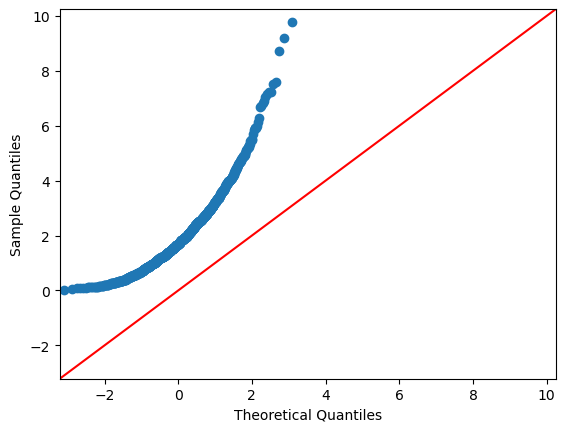

In [10]:
# 정규분포가 아닌 잔차의 Q-Q plot
gamma = np.random.default_rng().standard_gamma(shape = 2, size = 1000)

qqplot(gamma, line = "45")

plt.show()

- 정규분포에 가깝지 않은 잔차의 Q-Q plot은 y = x 에서 벗어나는 곡선을 생성

- 이런 종류의 결과를 얻으면 잔차의 분포가 정규분포와 유사하지 않으며, 모델이 데이터에 적합하지 않다는 신호

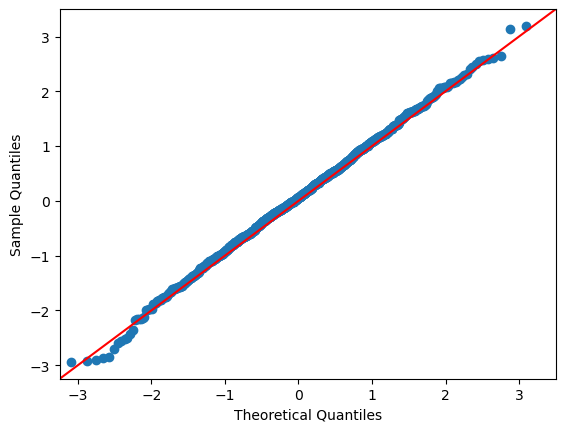

In [11]:
# 정규분포인 잔차의 Q-Q plot
normal = np.random.normal(size = 1000)

qqplot(normal, line = "45")

plt.show()

### 정량적 분석 이해 및 예시(융-박스 테스트)

- 잔차들 간에 상관관계가 없음을 증명

- 좋은 모델은 잔차가 백색소음에 가까우므로, 잔차가 정규분포이고 잔차들 간에 상관관계가 없어야 함

- 융-박스 테스트는 데이터 집단의 자기상관관계가 0과 유의하게 다른지 테스트하는 통계 검정
    - 귀무가설 : 잔차가 독립적이다(자기상관관계가 없다, 백색잡음이다)
    - 대립가설 : 잔차에 자기상관관계가 존재한다

## 잔차 분석 수행

- 앞서 찾은 ARMA(1, 1) 모델이 잘 작동하는지 확인

In [12]:
model = SARIMAX(ARMA_1_1, order = (1, 0, 1)) # ARMA(1, 1) 모델 정의
model_fit = model.fit(disp = False)
residuals = model_fit.resid # 모델의 잔차 저장

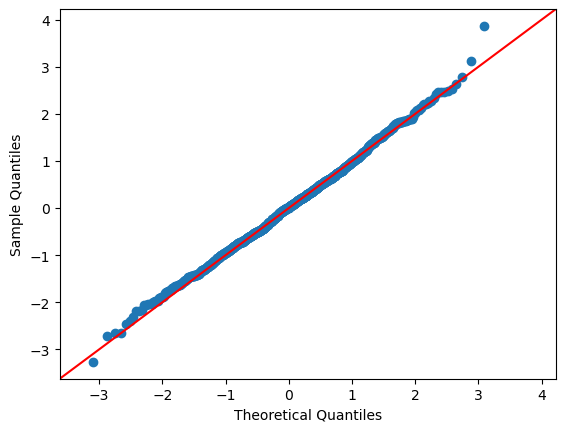

In [13]:
qqplot(residuals, line = "45")

plt.show()

- 정규분포 직선과 겹쳐져 정성적 관점에서 볼 때 모델의 잔차는 백색소음과 같이 정규분포를 보이며, 모델이 데이터에 잘 적합화 되었음

- plot_diagnostics 메서드를 사용하면 정성적 분석을 확장해 볼 수 있음
    - y에 대한 표준화된 잔차 : 시간에 따른 잔차 값을 그대로 그린 그래프
    - 히스토그램과 추정 밀도 : 잔차의 분포 모양을 히스토그램과 커널밀도 추정 곡선, 정규분포 곡선(N(0, 1))을 겹쳐서 보여줌
    - 정규 Q-Q plot : 잔차의 분위수를 정규분포의 이론적 분위수와 비교
    - ACF plot : 잔차의 자기상관함수
        - lag = 0 을 제외한 모든 막대가 신뢰구간 안에 들어와 있어야 함(자기상관관계가 없음)

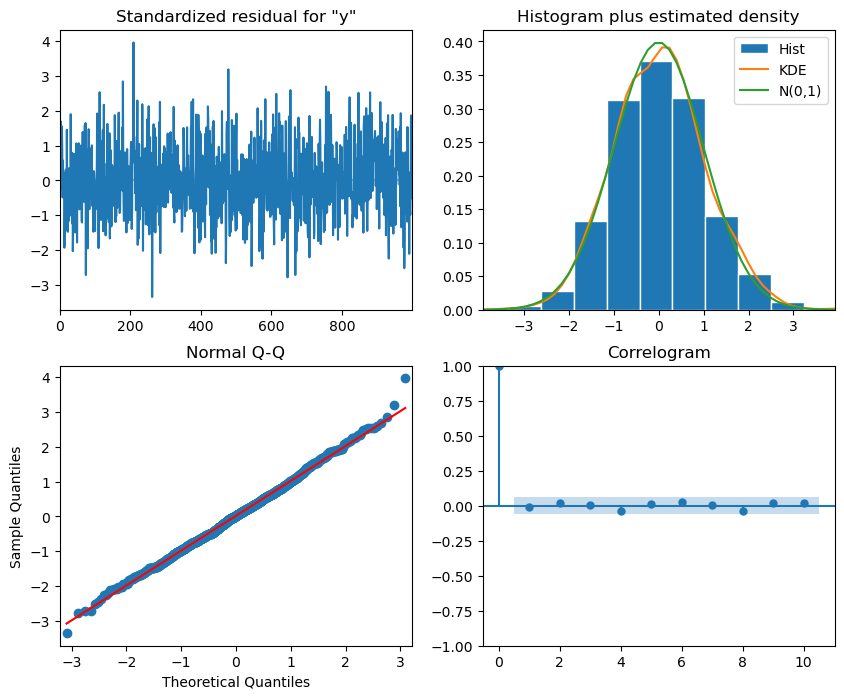

In [14]:
model_fit.plot_diagnostics(figsize = (10, 8))

plt.show()

In [15]:
tr = acorr_ljungbox(residuals, np.arange(1, 11, 1))

print(tr)

     lb_stat  lb_pvalue
1   0.030706   0.860897
2   0.528021   0.767966
3   0.540904   0.909817
4   2.079774   0.721089
5   2.271897   0.810385
6   2.896262   0.821750
7   2.900378   0.894063
8   4.418799   0.817501
9   4.787567   0.852419
10  5.246805   0.874093


- p값 목록이 모두 0.05를 초과하여 각 지연에서 귀무가설을 기각할 수 없으며, 잔차가 독립적으로 분포하고 상관관계가 없음을 뜻함

- 잔차가 정규분포이며 상관관계가 없으므로 잔차는 완전히 무작위이며 이는 데이터에 잘 맞는 모델임을 뜻함

# 데이터 센터의 대역폭 사용량 예측

- 대규모 데이터 센터의 대역폭 사용량을 예측하는 작업이 있다고 가정

- 대역폭의 정의는 전송할 수 있는 최대 데이터 전송률

- 기본 단위는 초당 비트(bits per seconds, bps)

- 대역폭 사용량을 예측할 수 있다면 컴퓨팅 자원을 더 잘 관리할 수 있음

- 예제 데이터는 2019년 1월 1일부터 시간당 대역폭 사용량을 나타내는 10000개의 데이터
    - 대역폭 단위는 초당 메가비트(Mbps)
        - 10^6 bps
     
- ARMA(p, q) 프로세스에 대한 일반적인 모델링 절차에 따라 데이터에 적합한 모델을 얻고 향후 2시간 동안의 대역폭 사용량 예측을 수행

In [16]:
df = pd.read_csv("./data/bandwidth.csv")

df.head()

,hourly_bandwidth
0,1000.496714
1,1000.969408
2,1002.046019
3,1004.702118
4,1007.447816


In [17]:
df.shape

(10000, 1)

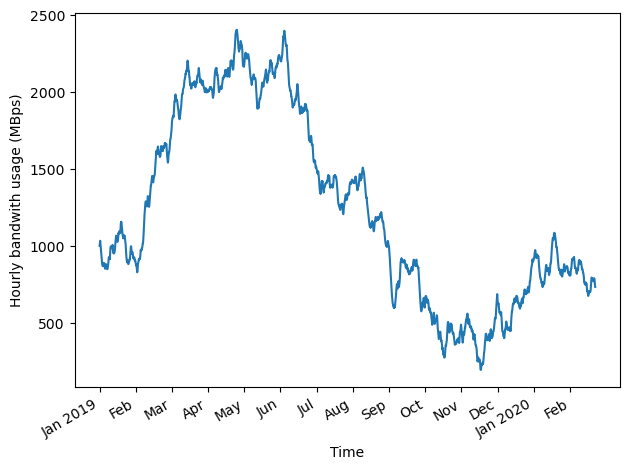

In [18]:
fig, ax = plt.subplots()

ax.plot(df['hourly_bandwidth'])
ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwith usage (MBps)')

plt.xticks(
    np.arange(0, 10000, 730), 
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- 데이터에 주기적인 패턴은 없으나 장기적인 추세가 있으며, 비정상 시계열일 가능성이 높음

In [19]:
ADF_result = adfuller(df["hourly_bandwidth"])

print(f"ADF Statistic: {ADF_result[0]}")
print(f"p-value: {ADF_result[1]}")

ADF Statistic: -0.8714653199452604
p-value: 0.7972240255014593


- p-value가 높아서 귀무가설을 기각할 수 없으며, 비정상 시계열임

- 정상성을 만족하게 만들기 위해 차분 적용

In [20]:
# 1차 차분
bandwidth_diff = np.diff(df["hourly_bandwidth"], n = 1)

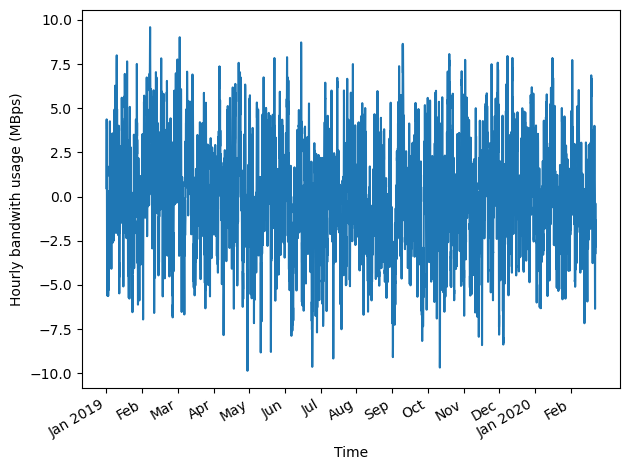

In [21]:
# 1차 차분된 데이터 시각화
fig, ax = plt.subplots()

ax.plot(bandwidth_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwith usage (MBps)')

plt.xticks(
    np.arange(0, 10000, 730), 
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [22]:
# 차분된 데이터 정상성 테스트
ADF_result = adfuller(bandwidth_diff)

print(f"ADF Statistic: {ADF_result[0]}")
print(f"p-value: {ADF_result[1]}")

ADF Statistic: -20.69485386378902
p-value: 0.0


- 차분된 수열은 정상성을 만족함

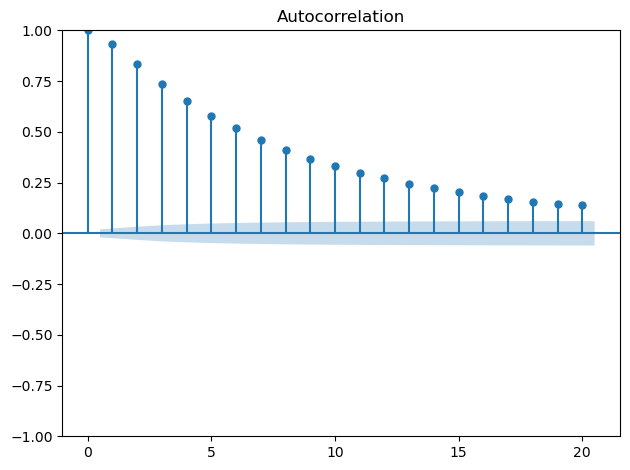

In [23]:
# 차분 데이터 acf 시각화
plot_acf(bandwidth_diff, lags = 20)

plt.tight_layout()
plt.show()

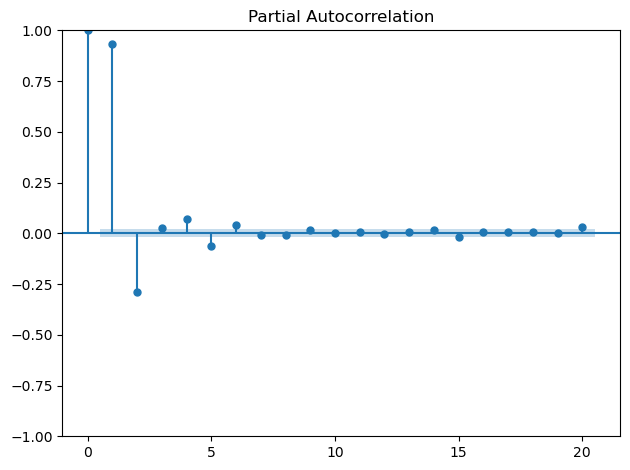

In [24]:
# 차분 데이터 pacf 시각화
plot_pacf(bandwidth_diff, lags = 20)

plt.tight_layout()
plt.show()

In [25]:
# 훈련 집합 테스트 집합 분할
df_diff = pd.DataFrame({"bandwidth_diff": bandwidth_diff})

train = df_diff[:-168]
test = df_diff[-168:] # 마지막 일주일의 데이터를 테스트 집합으로 할당

print(train.shape)
print(test.shape)

(9831, 1)
(168, 1)


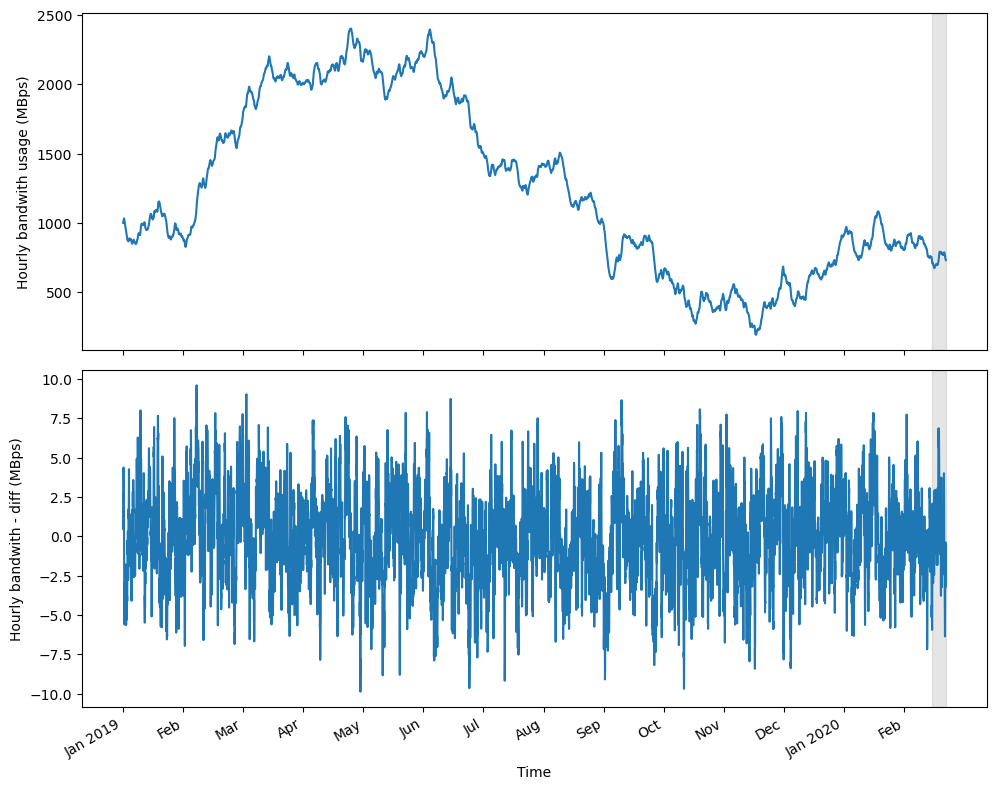

In [28]:
fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, sharex = True, figsize = (10, 8))

ax1.plot(df["hourly_bandwidth"])
ax1.set_xlabel('Time')
ax1.set_ylabel('Hourly bandwith usage (MBps)')
ax1.axvspan(9831, 10000, color = "#808080", alpha = 0.2)

ax2.plot(df_diff["bandwidth_diff"])
ax2.set_xlabel('Time')
ax2.set_ylabel('Hourly bandwith - diff (MBps)')
ax2.axvspan(9830, 9999, color = "#808080", alpha = 0.2)

plt.xticks(
    np.arange(0, 10000, 730), 
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- p와 q의 값으로 범위 0이상 3이하의 값을 시도

In [29]:
ps = range(0, 4, 1)
qs = range(0, 4, 1)

In [30]:
order_list = list(product(ps, qs))
order_list

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3)]

In [31]:
result_df = optimize_ARMA(train["bandwidth_diff"], order_list)
result_df

  0%|          | 0/16 [00:00<?, ?it/s]

,"(p, q)",AIC
0,"(3, 2)",27991.063879
1,"(2, 3)",27991.287509
2,"(2, 2)",27991.603598
3,"(3, 3)",27993.416924
4,"(1, 3)",28003.349550
5,"(1, 2)",28051.351401
6,"(3, 1)",28071.155496
7,"(3, 0)",28095.618186
8,"(2, 1)",28097.250766
9,"(2, 0)",28098.407664


- AIC의 차이가 2미만이라면 통계적으로 유의미한 차이가 없는, 거의 동등한 모델이라고 볼 수 있음

- AIC가 통계적으로 동등하다면, 파라미터 수가 적은 단순한 모델을 선택하는 게 원칙
    - (3, 2) -> 5개 파라미터
    - (2, 3) -> 5개 파라미터
    - (2, 2) -> 4개 파라미터

- ARMA(2, 2) 모델을 훈련 집합에 훈련한 뒤 잔차 분석 수행

In [33]:
model = SARIMAX(train["bandwidth_diff"], order = (2, 0, 2))
model_fit = model.fit(disp = False)
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:         bandwidth_diff   No. Observations:                 9831
Model:               SARIMAX(2, 0, 2)   Log Likelihood              -13990.802
Date:                Thu, 16 Jul 2026   AIC                          27991.604
Time:                        10:12:36   BIC                          28027.570
Sample:                             0   HQIC                         28003.788
                               - 9831                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3486      0.052      6.765      0.000       0.248       0.450
ar.L2          0.4743      0.047     10.000      0.000       0.381       0.567
ma.L1          0.8667      0.050     17.249      0.0

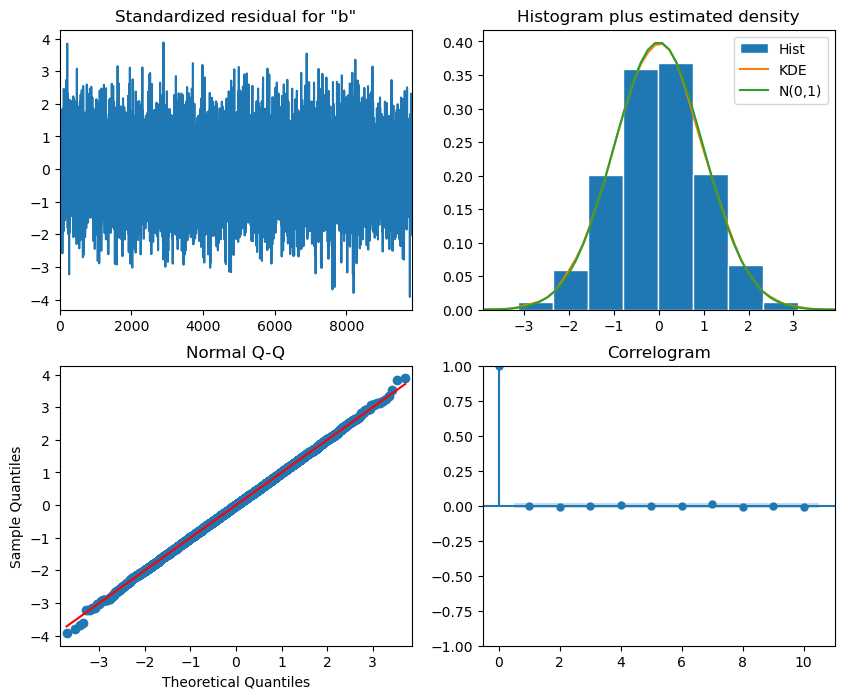

In [34]:
model_fit.plot_diagnostics(figsize = (10, 8))

plt.show()

- 어떠한 추세도 확인할 수 없고 평균이 일정하므로 잔차가 정상성을 만족할 가능성이 높음

- 정규분포와 유사한 분포를 확인할 수 있음

- ACF 그래프는 지연 0 이후 자기상관관계가 없음을 보여줌

In [36]:
residuals = model_fit.resid

result = acorr_ljungbox(residuals, np.arange(1, 11, 1))

print(result)

     lb_stat  lb_pvalue
1   0.042190   0.837257
2   0.418364   0.811247
3   0.520271   0.914416
4   0.850555   0.931545
5   0.850841   0.973678
6   1.111754   0.981019
7   2.124864   0.952607
8   3.230558   0.919067
9   3.248662   0.953615
10  3.588289   0.964015


- p값은 모두 0.05를 초과했으므로 잔차에 실제로 상관관계가 없음

- ARMA(2, 2) 모델은 잔차 분석에 대한 모든 검사를 통과했으므로 이제 이 모델을 사용하여 대역폭 사용량을 예측할 수 있음

In [39]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str, p = 0, q = 0) -> list:
    '''
    df : 전체 시계열 데이터
    train_len : 훈련 집합의 크기
    horizon : 테스트 집합의 크기. 예측할 값의 개수
    window : 한 번에 예측할 timestep 개수
    method : 사용할 모델 지정
    p : AR 프로세스의 차수
    q : MA 프로세스의 차수
    '''
    total_len = train_len + horizon

    if method == "mean":
        pred_mean = []

        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend([mean] * window)

        return pred_mean

    elif method == "last":
        pred_last_value = []

        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend([last_value] * window)

        return pred_last_value

    elif method == "ARMA":
        pred_ARMA = []

        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order = (p, 0, q))
            res = model.fit(disp = False) # disp : 훈련 과정을 화면에 출력할지 여부
            predictions = res.get_prediction(0, i + window - 1) # start, end
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ARMA.extend(oos_pred)

        return pred_ARMA

In [40]:
P = 2
Q = 2
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

In [41]:
pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, "mean")
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, "last")
pred_ARMA = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, "ARMA", P, Q)

In [42]:
test.loc[:, "pred_mean"] = pred_mean
test.loc[:, "pred_last_value"] = pred_last_value
test.loc[:, "pred_ARMA"] = pred_ARMA

test.head()

,bandwidth_diff,pred_mean,pred_last_value,pred_ARMA
9831,-5.943995,-0.028214,-5.791207,-5.460661
9832,-5.865194,-0.028214,-5.791207,-4.890626
9833,-3.197066,-0.029410,-5.865194,-5.335905
9834,-1.090197,-0.029410,-5.865194,-4.751731
9835,0.665291,-0.029840,-1.090197,-0.375596


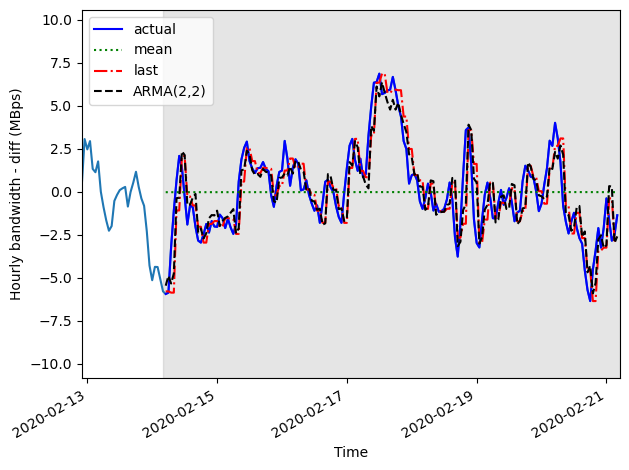

In [45]:
# 예측결과 시각화
fig, ax = plt.subplots()

ax.plot(df_diff['bandwidth_diff'])
ax.plot(test['bandwidth_diff'], 'b-', label='actual')
ax.plot(test['pred_mean'], 'g:', label='mean')
ax.plot(test['pred_last_value'], 'r-.', label='last')
ax.plot(test['pred_ARMA'], 'k--', label='ARMA(2,2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwidth - diff (MBps)')

ax.axvspan(9830, 9999, color='#808080', alpha=0.2)

ax.set_xlim(9800, 9999)

plt.xticks(
    [9802, 9850, 9898, 9946, 9994],
    ['2020-02-13', '2020-02-15', '2020-02-17', '2020-02-19', '2020-02-21'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [46]:
# 평균제곱오차(MSE)
mse_mean = mean_squared_error(test["bandwidth_diff"], test["pred_mean"])
mse_last = mean_squared_error(test["bandwidth_diff"], test["pred_last_value"])
mse_ARMA = mean_squared_error(test["bandwidth_diff"], test["pred_ARMA"])

print(mse_mean, mse_last, mse_ARMA)

6.306526957989325 2.2297582947733656 1.7690462114808116


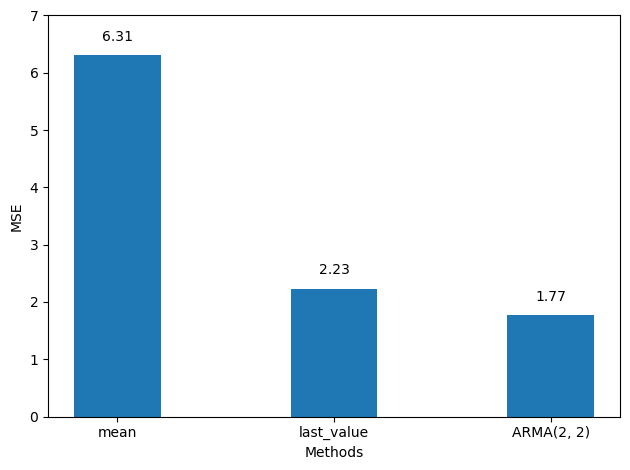

In [47]:
fig, ax = plt.subplots()

x = ["mean", "last_value", "ARMA(2, 2)"]
y = [mse_mean, mse_last, mse_ARMA]

ax.bar(x, y, width = 0.4)
ax.set_xlabel("Methods")
ax.set_ylabel("MSE")
ax.set_ylim(0, 7)

for index, value in enumerate(y):
    plt.text(x = index, y = value + 0.25, s = str(round(value, 2)), ha = "center")

plt.tight_layout()
plt.show()

In [48]:
# 차분 역변환
df["pred_bandwidth"] = pd.Series()
df["pred_bandwidth"][9832:] = df["hourly_bandwidth"].iloc[9832] + test["pred_ARMA"].cumsum()

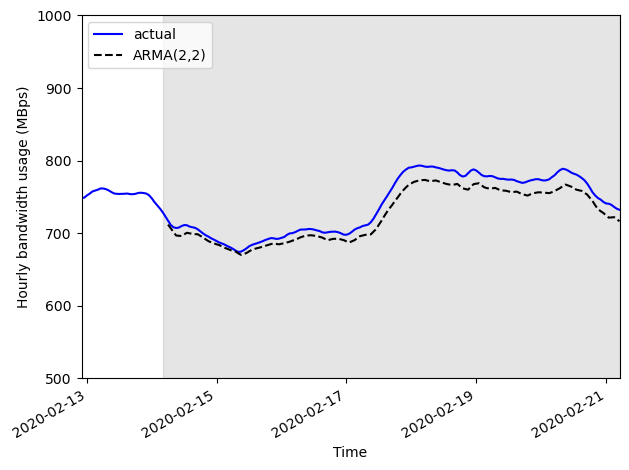

In [50]:
# 역변환 예측값 시각화
fig, ax = plt.subplots()

ax.plot(df['hourly_bandwidth'], 'b-', label='actual')
ax.plot(df['pred_bandwidth'], 'k--', label='ARMA(2,2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwidth usage (MBps)')

ax.axvspan(9830, 9999, color='#808080', alpha=0.2)

ax.set_xlim(9800, 9999)
ax.set_ylim(500, 1000)

plt.xticks(
    [9802, 9850, 9898, 9946, 9994],
    ['2020-02-13', '2020-02-15', '2020-02-17', '2020-02-19', '2020-02-21'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [52]:
mae_ARMA_undiff = mean_absolute_error(df["hourly_bandwidth"][9832:], df["pred_bandwidth"][9832:])

print(mae_ARMA_undiff)

14.000362775068186


- 평균적으로 예측값이 실제 대역폭 사용량과 14Mbps 정도 차이가 남

# 연습문제

## 예시로 사용했던 ARMA_1_1 에 대한 예측 수행

1. 훈련:테스트 비율 8:2 분할
2. ARMA(p, q) 모델, 평균 방법, 마지막 값 방법으로 예측 수행
3. 예측값 시각화
4. MSE 모델 평가

In [53]:
df = pd.DataFrame({"value" : ARMA_1_1})

df.shape

(1000, 1)

In [54]:
train = df[:800]
test = df[800:]

In [55]:
P = 1
Q = 1
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 1

In [56]:
pred_mean = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "mean")
pred_last_value = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "last")
pred_ARMA = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "ARMA", P, Q)

In [57]:
test.loc[:, "pred_mean"] = pred_mean
test.loc[:, "pred_last_value"] = pred_last_value
test.loc[:, "pred_ARMA"] = pred_ARMA

test.head()

,value,pred_mean,pred_last_value,pred_ARMA
800,1.084218,-0.022669,0.361071,0.146811
801,0.686203,-0.021287,1.084218,1.183808
802,-0.141873,-0.020405,0.686203,-0.255567
803,-0.422585,-0.020556,-0.141873,0.062876
804,-0.989997,-0.021056,-0.422585,-0.571610


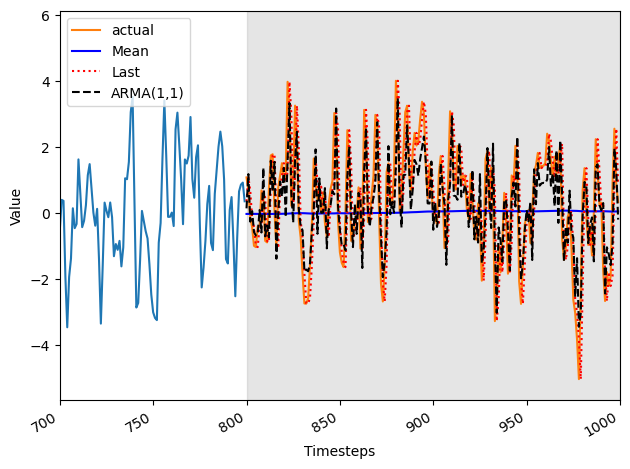

In [58]:
fig, ax = plt.subplots()

ax.plot(train)
ax.plot(test['value'], label='actual')
ax.plot(test['pred_mean'], "b-", label='Mean')
ax.plot(test['pred_last_value'], "r:", label='Last')
ax.plot(test['pred_ARMA'], 'k--', label='ARMA(1,1)')

ax.legend(loc=2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

ax.axvspan(800, 1000, color='#808080', alpha=0.2)

ax.set_xlim(700, 1000)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [59]:
mse_mean = mean_squared_error(test["value"], test["pred_mean"])
mse_last = mean_squared_error(test["value"], test["pred_last_value"])
mse_ARMA = mean_squared_error(test["value"], test["pred_ARMA"])

print(mse_mean, mse_last, mse_ARMA)

2.6792528451659092 1.6761458178498734 0.928195868947464


## 시계열 예측 수행하기 2

- 마지막 20%는 테스트 데이터

- 일반적 모델링 절차 참고해서 예측 후 모델 평가까지 수행

In [70]:
process = np.load("./data/q6-2.npy")

In [71]:
process.shape

(1000,)

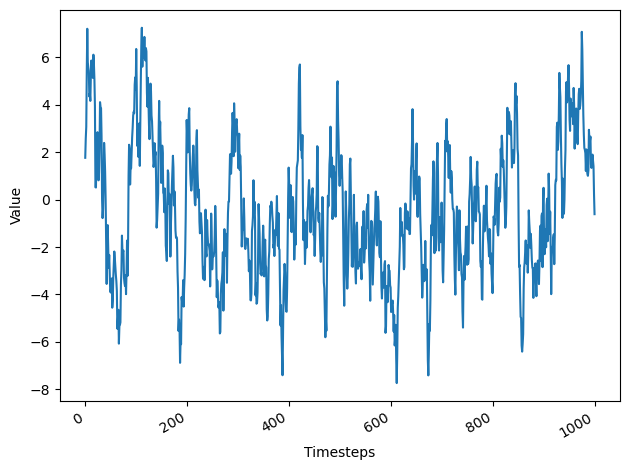

In [72]:
fig, ax = plt.subplots()

ax.plot(process)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [73]:
# 정상성 테스트
ADF_result = adfuller(process)

print(f"ADF Statistic: {ADF_result[0]}")
print(f"p-value: {ADF_result[1]}")

ADF Statistic: -5.015019396964121
p-value: 2.0723253549934467e-05


In [74]:
df = pd.DataFrame({"value" : process})

train = df[:-200]
test = df[-200:]

In [75]:
train.shape

(800, 1)

In [76]:
test.shape

(200, 1)

In [77]:
# (p, q) 조합 목록
ps = range(0, 4, 1)
qs = range(0, 4, 1)

order_list = list(product(ps, qs))

In [78]:
result_df = optimize_ARMA(train["value"], order_list)
result_df

  0%|          | 0/16 [00:00<?, ?it/s]

,"(p, q)",AIC
0,"(2, 1)",2271.826713
1,"(3, 2)",2272.814672
2,"(3, 1)",2273.218231
3,"(2, 2)",2273.253752
4,"(3, 3)",2274.725548
5,"(2, 3)",2275.103666
6,"(1, 3)",2292.951207
7,"(1, 2)",2314.716043
8,"(3, 0)",2349.498213
9,"(1, 1)",2354.288576


In [79]:
model = SARIMAX(train["value"], order = (2, 0, 1))
model_fit = model.fit(disp = False)

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  800
Model:               SARIMAX(2, 0, 1)   Log Likelihood               -1131.913
Date:                Thu, 16 Jul 2026   AIC                           2271.827
Time:                        12:48:58   BIC                           2290.565
Sample:                             0   HQIC                          2279.025
                                - 800                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2899      0.038      7.655      0.000       0.216       0.364
ar.L2          0.5652      0.037     15.364      0.000       0.493       0.637
ma.L1          0.9340      0.017     53.401      0.0

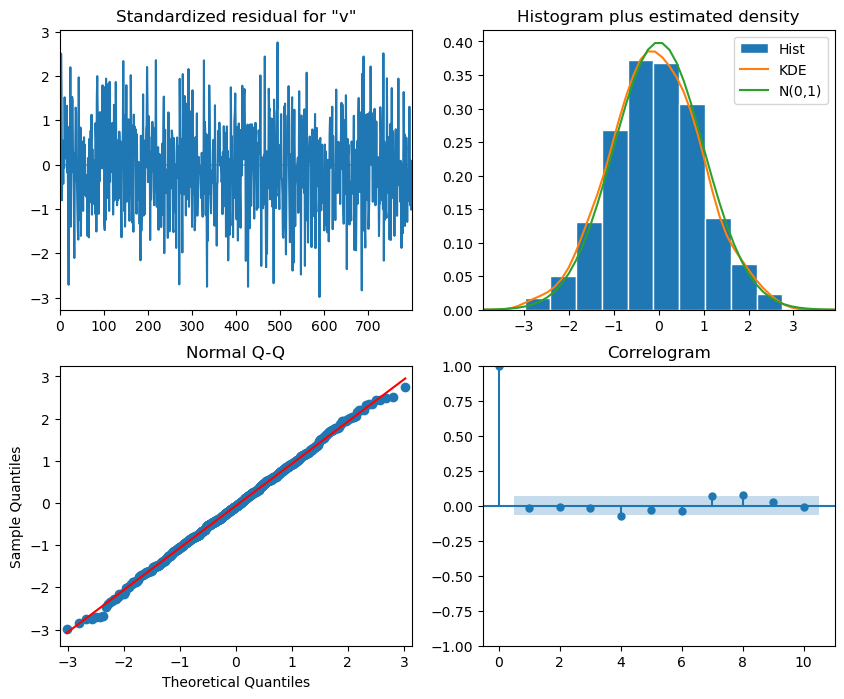

In [80]:
model_fit.plot_diagnostics(figsize = (10, 8))
plt.show()

In [81]:
residuals = model_fit.resid

rt = acorr_ljungbox(residuals, np.arange(1, 11, 1))
print(rt)

      lb_stat  lb_pvalue
1    0.189845   0.663046
2    0.214729   0.898198
3    0.284715   0.962877
4    4.400608   0.354496
5    5.076662   0.406596
6    6.016203   0.421377
7    9.686415   0.207051
8   14.112100   0.078890
9   14.773455   0.097350
10  14.827345   0.138484


In [82]:
P = 2
Q = 1
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 1

In [83]:
pred_mean = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "mean")
pred_last_value = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "last")
pred_ARMA = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "ARMA", P, Q)

In [84]:
test.loc[:, "pred_mean"] = pred_mean
test.loc[:, "pred_last_value"] = pred_last_value
test.loc[:, "pred_ARMA"] = pred_ARMA

test.head()

,value,pred_mean,pred_last_value,pred_ARMA
800,-2.416364,-0.779178,-3.944332,-3.856792
801,-0.713708,-0.781222,-2.416364,-1.583736
802,-0.793952,-0.781138,-0.713708,-0.758685
803,-1.061797,-0.781154,-0.793952,-0.664782
804,-0.158547,-0.781503,-1.061797,-1.125332


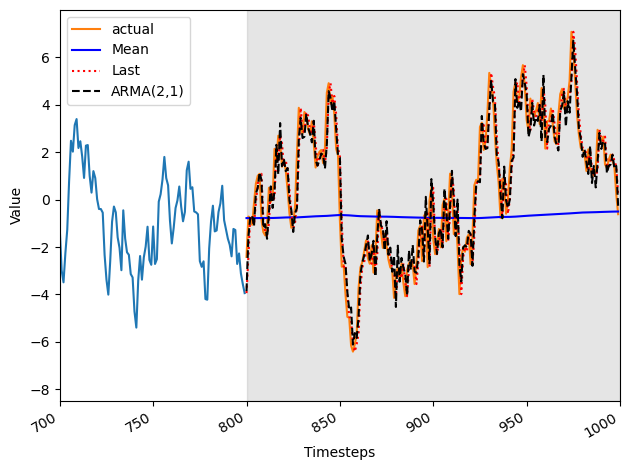

In [85]:
fig, ax = plt.subplots()

ax.plot(train)
ax.plot(test['value'], label='actual')
ax.plot(test['pred_mean'], "b-", label='Mean')
ax.plot(test['pred_last_value'], "r:", label='Last')
ax.plot(test['pred_ARMA'], 'k--', label='ARMA(2,1)')

ax.legend(loc=2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

ax.axvspan(800, 1000, color='#808080', alpha=0.2)

ax.set_xlim(700, 1000)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [86]:
mse_mean = mean_squared_error(test["value"], test["pred_mean"])
mse_last = mean_squared_error(test["value"], test["pred_last_value"])
mse_ARMA = mean_squared_error(test["value"], test["pred_ARMA"])

print(mse_mean, mse_last, mse_ARMA)

9.465617582298414 1.0654146706723975 0.8863202852198845


# 정리

- ARMA(p, q) 모델은 AR(p)와 MA(q) 를 결합한 모델임

- ARMA(p, q) 프로세스는 ACF 그래프와 PACF 그래프 모두에서 감쇄 패턴이나 사인 곡선 패턴을 보임
    - 따라서 차수 p와 q를 추정하는 데 사용할 수 없음
 
- 일반적 모델링 절차는 ACF 그래프와 PACF 그래프에 의존하지 않음
    - 대신 많은 ARMA(p, q) 모델을 훈련하고 모델을 선택하며 잔차 분석을 수행함
 
- 모델 선택은 AIC(아카이케 정보 기준)를 사용하여 수행
    - 모델의 정보 손실 수준을 정량화 하는 지표
    - 모델 매개변수 개수 및 데이터 적합도와 관련이 있음
    - AIC가 낮을수록 더 좋은 모델임

- 좋은 모델의 잔차는 백색소음에 가까워야 하며, 상관관계가 없고 정규분포이며 독립적이어야 함

- Q-Q plot은 두 분포를 비교하기 위한 시각화 도구임
    - 잔차의 분포를 이론적 정규분포와 비교
    - y = x 직선에 겹쳐진 직선을 보이면 두 분포가 유사하다 = 정규분포를 보인다 는 뜻

- 융-박스 테스트를 통해 잔차의 상관관계 여부를 확인
    - 귀무가설 : 데이터가 독립적이며 상관관계가 없다
    - 대립가설 : 상관관계가 있다